## Importing dataset

In [ ]:
# IMPORTANT: SOME KAGGLE DATA SOURCES ARE PRIVATE
# RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES.
import kagglehub
kagglehub.login()

Kaggle credentials set.
Kaggle credentials successfully validated.


In [ ]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.
tirathbhathawala_dataset_splitting_aug_v4_augmented_dataset_path = kagglehub.dataset_download('tirathbhathawala/dataset-splitting-aug-v4-augmented-dataset')
print('Data source import complete.')

100%|██████████| 69.5M/69.5M [00:00<00:00, 166MB/s]

Extracting files...


Data source import complete.


In [ ]:
tirathbhathawala_dataset_splitting_aug_v4_augmented_dataset_path

'/root/.cache/kagglehub/datasets/tirathbhathawala/dataset-splitting-aug-v4-augmented-dataset/versions/1'

In [ ]:
dataset_path = tirathbhathawala_dataset_splitting_aug_v4_augmented_dataset_path

In [ ]:
import numpy as np
import pandas as pd
import os

In [ ]:
# This path MUST match the final output directory from your previous script
AUGMENTED_DIR = f'{dataset_path}/balanced_augmented_dataset'
CLASSES = [
    'Comminuted', 'Greenstick', 'Healthy', 'Oblique Displaced', 'Oblique',
    'Spiral', 'Transverse Displaced', 'Transverse', 'Linear', 'Segmental'
]

summary_data = []
total_files = 0

print("=" * 60)
print(f"Inspecting contents of: {AUGMENTED_DIR}")
print("=" * 60)

Inspecting contents of: /root/.cache/kagglehub/datasets/tirathbhathawala/dataset-splitting-aug-v4-augmented-dataset/versions/1/balanced_augmented_dataset


In [ ]:

# Walk through the directory structure: /balanced_augmented_dataset/split/class_name
for split in ['train', 'val', 'test']:
    split_path = os.path.join(AUGMENTED_DIR, split)

    # Check if the split directory exists
    if not os.path.exists(split_path):
        print(f"❌ WARNING: Split directory not found: {split_path}")
        continue

    for cls in CLASSES:
        cls_dir = cls.replace(' ', '_')
        path = os.path.join(split_path, cls_dir)

        count = 0
        if os.path.exists(path):
            count = len(os.listdir(path))
            total_files += count

        summary_data.append({
            'Split': split,
            'Class': cls,
            'Count': count
        })

        # Print a quick check for non-empty folders
        if count > 0:
             print(f"Found {count:5d} files in -> {split}/{cls_dir}")

Found   296 files in -> train/Comminuted
Found   232 files in -> train/Greenstick
Found   176 files in -> train/Healthy
Found   296 files in -> train/Oblique_Displaced
Found   156 files in -> train/Oblique
Found   204 files in -> train/Spiral
Found   296 files in -> train/Transverse_Displaced
Found   296 files in -> train/Transverse
Found    16 files in -> val/Comminuted
Found    12 files in -> val/Greenstick
Found    10 files in -> val/Healthy
Found    16 files in -> val/Oblique_Displaced
Found     9 files in -> val/Oblique
Found    11 files in -> val/Spiral
Found    16 files in -> val/Transverse_Displaced
Found    16 files in -> val/Transverse
Found    17 files in -> test/Comminuted
Found    13 files in -> test/Greenstick
Found    10 files in -> test/Healthy
Found    17 files in -> test/Oblique_Displaced
Found     9 files in -> test/Oblique
Found    12 files in -> test/Spiral
Found    17 files in -> test/Transverse_Displaced
Found    17 files in -> test/Transverse


In [ ]:
# ============================================
# FINAL SUMMARY TABLE
# ============================================

df_summary = pd.DataFrame(summary_data)
summary_pivot = df_summary.pivot(index='Class', columns='Split', values='Count')

print("\n" + "=" * 60)
print("📊 FINAL AUGMENTED DATASET DISTRIBUTION")
print(f"Total files processed: {total_files}")
print("=" * 60)
print(summary_pivot.to_string())
print("=" * 60)


📊 FINAL AUGMENTED DATASET DISTRIBUTION
Total files processed: 2170
Split                 test  train  val
Class                                 
Comminuted              17    296   16
Greenstick              13    232   12
Healthy                 10    176   10
Linear                   0      0    0
Oblique                  9    156    9
Oblique Displaced       17    296   16
Segmental                0      0    0
Spiral                  12    204   11
Transverse              17    296   16
Transverse Displaced    17    296   16


## Model Finetuning

In [ ]:
!pip install --upgrade transformers huggingface-hub accelerate -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.1/566.1 kB 6.7 MB/s eta 0:00:00


In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Dropout, Input, GlobalAveragePooling2D, Lambda
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from transformers import TFAutoModelForImageClassification, AutoImageProcessor

In [ ]:
# Enable soft device placement for robustness, but the core fix is the device scope.
print("Setting TensorFlow soft device placement...")
tf.config.set_soft_device_placement(True)

# Configuration and Paths (Unchanged)
MODEL_ID = "facebook/convnextv2-huge-22k-384"
# AUGMENTED_DIR = '/kaggle/working/balanced_augmented_dataset'
IMG_SIZE = (384, 384)
BATCH_SIZE = 16
EPOCHS = 10
TRAIN_DIR = os.path.join(AUGMENTED_DIR, 'train')
VAL_DIR = os.path.join(AUGMENTED_DIR, 'val')
TEST_DIR = os.path.join(AUGMENTED_DIR, 'test')

print("Configuration complete. Preparing data generators...")

Setting TensorFlow soft device placement...
Configuration complete. Preparing data generators...


In [ ]:
raw_datagen = ImageDataGenerator()

In [ ]:
train_generator = raw_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True
)

Found 1952 images belonging to 8 classes.


In [ ]:
val_generator = raw_datagen.flow_from_directory(
    VAL_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

Found 106 images belonging to 8 classes.


In [ ]:
test_generator = raw_datagen.flow_from_directory(
    TEST_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

Found 112 images belonging to 8 classes.


In [ ]:
class_names = list(train_generator.class_indices.keys())
NUM_CLASSES = len(class_names)

id2label = {v: k for k, v in train_generator.class_indices.items()}
label2id = {k: v for k, v in train_generator.class_indices.items()}

print(f"Loaded {NUM_CLASSES} classes: {class_names}")

Loaded 8 classes: ['Comminuted', 'Greenstick', 'Healthy', 'Oblique', 'Oblique_Displaced', 'Spiral', 'Transverse', 'Transverse_Displaced']


In [ ]:
print(f"\nLoading Hugging Face model: {MODEL_ID}")

# Determine target device for loading
target_device = "/cpu:0"
if tf.config.list_physical_devices('GPU'):
    target_device = "/gpu:0"
    print("✅ Forcing model load onto GPU:0 to prevent cross-device errors.")
else:
    print("⚠️ GPU not detected. Loading onto CPU.")


Loading Hugging Face model: facebook/convnextv2-huge-22k-384
✅ Forcing model load onto GPU:0 to prevent cross-device errors.


In [ ]:
with tf.device(target_device):
    hf_model_full = TFAutoModelForImageClassification.from_pretrained(
    	MODEL_ID,
    	from_pt=True,
        ignore_mismatched_sizes=True
    )

# Extract the backbone layer object
hf_model_backbone = hf_model_full.layers[0]
hf_model_backbone.trainable = False

config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/2.64G [00:00<?, ?B/s]

TensorFlow and JAX classes are deprecated and will be removed in Transformers v5. We recommend migrating to PyTorch classes or pinning your version of Transformers.
All PyTorch model weights were used when initializing TFConvNextV2ForImageClassification.

All the weights of TFConvNextV2ForImageClassification were initialized from the PyTorch model.
If your task is similar to the task the model of the checkpoint was trained on, you can already use TFConvNextV2ForImageClassification for predictions without further training.


In [ ]:
print("\nBuilding and compiling Keras model...")

# Keras Functional API definition
input_tensor = Input(shape=IMG_SIZE + (3,), name='image_input')

# 1. Custom Preprocessing Layer
x = Lambda(lambda img: tf.image.convert_image_dtype(img, tf.float32) * 255.0, name='preprocess')(input_tensor)

# Output dimensions
OUTPUT_SPATIAL_SIZE = 12
OUTPUT_CHANNELS = 2816
OUTPUT_SHAPE = (OUTPUT_SPATIAL_SIZE, OUTPUT_SPATIAL_SIZE, OUTPUT_CHANNELS)


Building and compiling Keras model...


In [ ]:
def call_hf_backbone(inputs):
    # Transpose input: (B, H, W, C) -> (B, C, H, W)
    transposed_inputs = tf.transpose(inputs, perm=[0, 3, 1, 2])

    # Get features from backbone (output is (B, C, H, W))
    features = hf_model_backbone(transposed_inputs, training=False)[0]

    # Transpose output back: (B, C, H, W) -> (B, H, W, C)
    return tf.transpose(features, perm=[0, 2, 3, 1])

In [ ]:
x = Lambda(
    call_hf_backbone,
    output_shape=OUTPUT_SHAPE,
    name='hf_backbone_wrapper'
)(x)

In [ ]:
# 3. Custom Classification Head
x = GlobalAveragePooling2D(name='pooling')(x)
x = Dense(512, activation='relu', name='dense_1')(x)
x = Dropout(0.3, name='dropout_1')(x)
output_tensor = Dense(NUM_CLASSES, activation='softmax', name='final_classifier')(x)

In [ ]:
model = Model(inputs=input_tensor, outputs=output_tensor)

In [ ]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ image_input (InputLayer)        │ (None, 384, 384, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ preprocess (Lambda)             │ (None, 384, 384, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hf_backbone_wrapper (Lambda)    │ (None, 12, 12, 2816)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pooling                         │ (None, 2816)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 512)            │     1,442,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ final_classifier (Dense)        │ (None, 8)              │         4,104 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,446,408 (5.52 MB)

 Trainable params: 1,446,408 (5.52 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
callbacks = [
    EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=2, min_lr=1e-6),
    ModelCheckpoint('best_convnextv2_hf_fracture_classifier.h5', monitor='val_loss', save_best_only=True)
]

In [ ]:
history = model.fit(
    train_generator,
    epochs=EPOCHS,
    validation_data=val_generator,
    callbacks=callbacks,
    verbose=1
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
122/122 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.1747 - loss: 6.0519

122/122 ━━━━━━━━━━━━━━━━━━━━ 472s 3s/step - accuracy: 0.1750 - loss: 6.0329 - val_accuracy: 0.2264 - val_loss: 1.9034 - learning_rate: 0.0010
Epoch 2/10
122/122 ━━━━━━━━━━━━━━━━━━━━ 379s 3s/step - accuracy: 0.2886 - loss: 1.8963 - val_accuracy: 0.2736 - val_loss: 1.9510 - learning_rate: 0.0010
Epoch 3/10
122/122 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.3219 - loss: 1.7903

122/122 ━━━━━━━━━━━━━━━━━━━━ 378s 3s/step - accuracy: 0.3219 - loss: 1.7901 - val_accuracy: 0.2736 - val_loss: 1.8763 - learning_rate: 0.0010
Epoch 4/10
122/122 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.3184 - loss: 1.7018

122/122 ━━━━━━━━━━━━━━━━━━━━ 378s 3s/step - accuracy: 0.3185 - loss: 1.7019 - val_accuracy: 0.2925 - val_loss: 1.8409 - learning_rate: 0.0010
Epoch 5/10
122/122 ━━━━━━━━━━━━━━━━━━━━ 378s 3s/step - accuracy: 0.3421 - loss: 1.6557 - val_accuracy: 0.3113 - val_loss: 1.8572 - learning_rate: 0.0010
Epoch 6/10
122/122 ━━━━━━━━━━━━━━━━━━━━ 378s 3s/step - accuracy: 0.3823 - loss: 1.6078 - val_accuracy: 0.3019 - val_loss: 1.9144 - learning_rate: 0.0010
Epoch 7/10
122/122 ━━━━━━━━━━━━━━━━━━━━ 379s 3s/step - accuracy: 0.3921 - loss: 1.5533 - val_accuracy: 0.3019 - val_loss: 1.8632 - learning_rate: 2.0000e-04


## Model Evaluation

In [ ]:
print("\n" + "=" * 60)
print("FINAL MODEL EVALUATION ON TEST SET")
print("=" * 60)

loss, accuracy = model.evaluate(test_generator, verbose=0)

print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")


FINAL MODEL EVALUATION ON TEST SET
Test Loss: 1.8041
Test Accuracy: 0.2857


In [ ]:
model.load_weights('best_convnextv2_hf_fracture_classifier.h5')

In [ ]:
print("\n" + "=" * 60)
print("BEST MODEL EVALUATION ON TEST SET")
print("=" * 60)

loss, accuracy = model.evaluate(test_generator, verbose=0)

print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")


BEST MODEL EVALUATION ON TEST SET
Test Loss: 1.8041
Test Accuracy: 0.2857


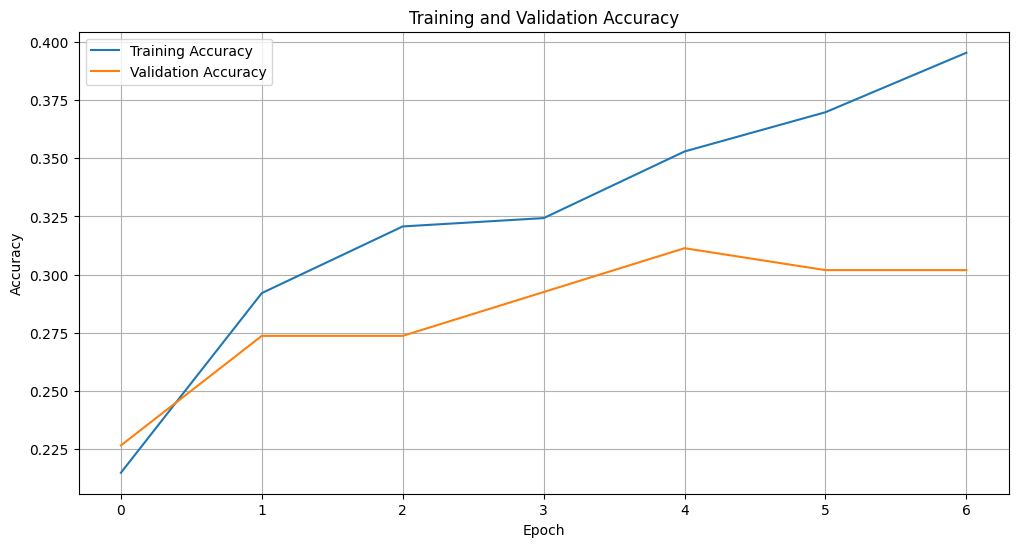

In [ ]:
import matplotlib.pyplot as plt

# Plot training and validation accuracy
plt.figure(figsize=(12, 6))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

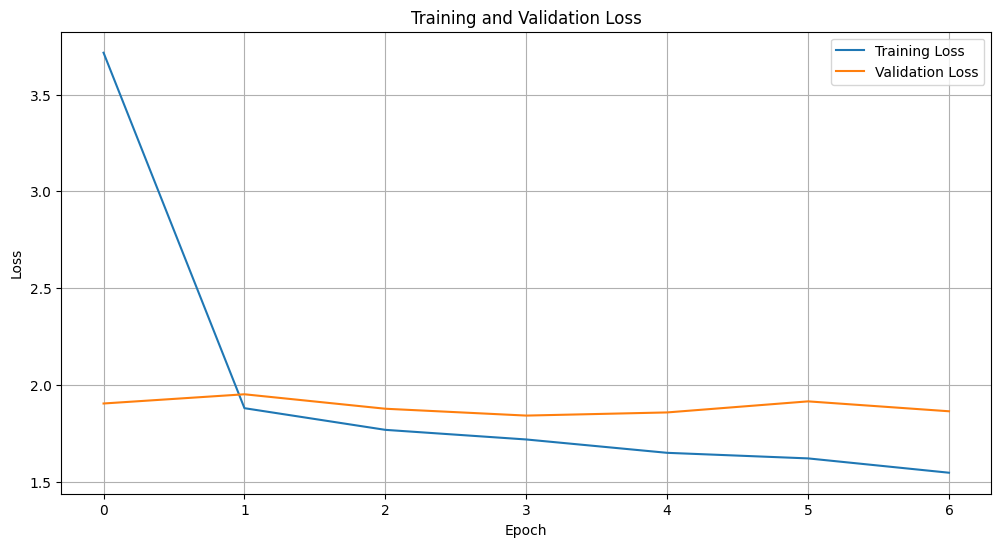

In [ ]:
# Plot training and validation loss
plt.figure(figsize=(12, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()